In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import pandas as pd

# 1. Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split into Training and Testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nMacro-Average F1 Score: {f1_macro:.4f}")

# 6. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

Confusion Matrix:
[[40  3]
 [ 1 70]]

Macro-Average F1 Score: 0.9623

Top 5 Most Important Features:
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
dtype: float64


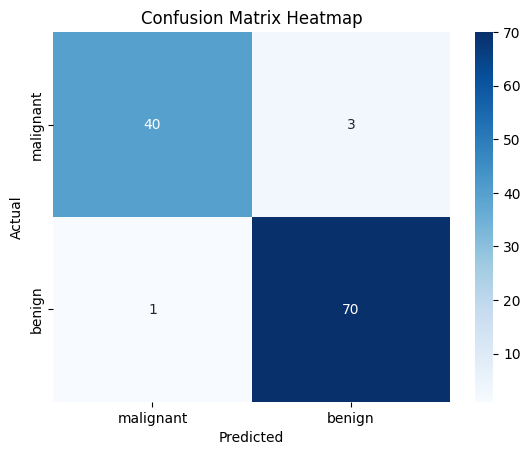

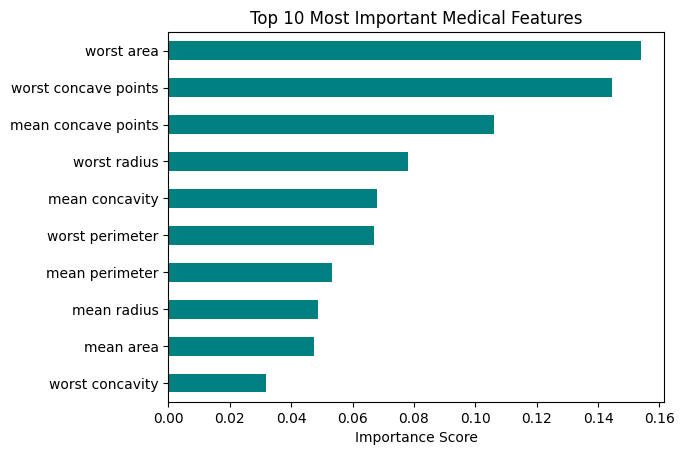

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc

# 1. Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Visualization: Confusion Matrix
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 5. Visualization: Top 10 Features
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names).sort_values(ascending=False)
importances.head(10).plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 10 Most Important Medical Features')
plt.xlabel('Importance Score')
plt.show()

In [9]:
# Pick the first patient from our test set
sample_patient = X_test.iloc[0:1] # or X_test.iloc[0].values.reshape(1, -1) process as numpy array
actual_diagnosis = y_test[0]

# Make the prediction
prediction = rf_model.predict(sample_patient)
probability = rf_model.predict_proba(sample_patient)

# Map the numbers to labels (0 = Malignant, 1 = Benign)
label = "Benign" if prediction[0] == 1 else "Malignant"

print(f"Prediction for this patient: {label}")
print(f"Confidence: {probability[0][prediction[0]]*100:.2f}%")
print(f"Actual Diagnosis in record: {'Benign' if actual_diagnosis == 1 else 'Malignant'}")

Prediction for this patient: Benign
Confidence: 97.00%
Actual Diagnosis in record: Benign
